GO THROUGH MUMSHAD + YT VIDEOs

HTTPS = HTTP over TLS, first the handshake happens and then the HTTP happens

involves, external IP and port 443 usually, like below

manojcloudvm@instance-20260404-024439:~$ curl -ik https://136.114.99.52:443/
HTTP/1.1 200 OK
Server: nginx/1.22.1
Date: Tue, 07 Apr 2026 01:49:25 GMT
Content-Type: application/json
Content-Length: 50
Connection: keep-alive

{
  "message": "app1 is running",
  "path": "/"
}

> you will see this better with --->curl -vk https://136.114.99.52/

check


Moreover,
> COMMAND: openssl s_client -connect 127.0.0.1:443 -servername localhost
> RUN-->: openssl s_client -connect 136.114.99.52:443

What it does

opens a connection to 136.114.99.52 on 443
attempts a TLS handshake
shows:
server certificate
issuer/subject
protocol version
cipher used
verification result

Why it is useful

prove the port is really speaking TLS
inspect the cert being served
debug cert/handshake issues
check expiry / chain / trust problems

In your case

curl -ik https://... proved HTTPS works
openssl s_client gives deeper TLS details

Good interview line

“I use openssl s_client when I want low-level visibility into the TLS handshake and the exact certificate a server is presenting.”

Yes. These are the most useful **practical** ones:

**1. View cert details**

```bash id="xxy3jk"
openssl x509 -in cert.crt -text -noout
```

* Read subject, issuer, expiry, SANs

**2. Check cert expiry only**

```bash id="n5vx8s"
openssl x509 -in cert.crt -noout -dates
```

**3. Check private key**

```bash id="vrw2gw"
openssl rsa -in private.key -check
```

**4. Verify cert matches key**

```bash id="0bi6an"
openssl x509 -noout -modulus -in cert.crt | openssl md5
openssl rsa  -noout -modulus -in private.key | openssl md5
```

* Hashes should match

**5. Test remote TLS and show cert chain**

```bash id="onlzwc"
openssl s_client -connect example.com:443 -showcerts
```

**6. Test with SNI**

```bash id="o75hbe"
openssl s_client -connect example.com:443 -servername example.com
```

* Very important for virtual hosts / multiple HTTPS sites

**7. Generate private key**

```bash id="uqnqsp"
openssl genrsa -out private.key 2048
```

**8. Generate CSR**

```bash id="q4z4a4"
openssl req -new -key private.key -out server.csr
```

**9. Make self-signed cert**

```bash id="v9u8w0"
openssl req -x509 -newkey rsa:2048 -nodes -keyout key.key -out cert.crt -days 365
```

**10. Check supported TLS/cipher quickly**

```bash id="e6h14o"
openssl ciphers -v
```

**Best interview/admin ones to remember**

* `openssl s_client`
* `openssl x509 -text -noout`
* `openssl req`
* `openssl rsa -check`

**Strong interview line**

* “I mainly use OpenSSL to inspect certificates, verify key-cert pairing, generate CSRs, and test real TLS handshakes against live endpoints.”


The Foundation: TCP 3-Way Handshake
Before TLS can even start, a reliable connection must be established. According to the sources, this follows three steps:
SYN: The client sends a synchronization packet with a Sequence Number
.
SYN + ACK: The server responds, synchronizing its own number and acknowledging the client's
.
ACK: The client sends a final acknowledgement to establish the connection
.

--------------------------------------------------------------------------------
TLS Basics (General Technical Knowledge)
Note: The following specific TLS details are not explicitly detailed in the provided sources, which focus more on TCP and general networking. You may wish to independently verify these concepts.
The TLS Handshake: This happens after the TCP connection is "ESTABLISHED"
. Its goal is to negotiate encryption keys and verify the server's identity so that data transferred via protocols like HTTPS (Port 443) remains secure
.
Certificate Subject: This is the identity of the certificate holder. In a web context, the "Subject" is usually the domain name (e.g., google.com) that the certificate is protecting.
Issuer: This is the Certificate Authority (CA)—the trusted third party that verified the identity of the "Subject" and signed the certificate to prove it is legitimate.
Self-Signed Certificate: This is a certificate where the Issuer and the Subject are the same. Because no trusted third-party CA has verified it, browsers and tools will not trust it by default.
Why curl fails without -k
When you use the curl command to transfer data from a URL, it performs a security check on the certificate
.
The Failure: If a server uses a self-signed certificate or one from an unknown issuer, curl will block the connection to protect you from potential "Man-in-the-Middle" attacks.
The -k (or --insecure) Flag: This flag tells curl to skip the certificate validation step. It allows the connection to proceed even if the certificate is untrusted. In an interview, you should mention that while -k is useful for testing, it is insecure for production environments.
Interview Strategy
If asked about a "connection failure," always ask if the failure is happening at the TCP level (could be a firewall or down service) or the TLS level (likely a certificate mismatch or expired cert).

Go through Mumshad Course on CERTS

It is used to **test a TLS/SSL connection** to a server.

Your command:

```bash id="xvrswn"
openssl s_client -connect 127.0.0.1:443
```

means:

* connect to `127.0.0.1`
* on port `443`
* try a **TLS handshake**
* show certificate and handshake details

**When it comes in handy**

* Checking whether HTTPS is actually working
* Seeing which certificate the server presents
* Verifying expiry, subject, issuer
* Testing TLS handshake problems
* Debugging “site not secure”, cert mismatch, chain issues

**Is it only when certs are configured?**

* It is useful when a service is supposed to speak **TLS**
* If nothing TLS is configured on that port, handshake will fail
* So yes, mostly used for HTTPS/TLS-enabled services

**Typical use cases**

* Nginx/Apache/Ingress on 443
* SMTP with TLS
* LDAPS
* Any TLS-enabled endpoint

**Good interview line**

* “`openssl s_client` is a low-level TLS debugging tool. I use it to confirm that a service is speaking TLS, inspect the presented certificate, and troubleshoot handshake or trust issues.”


manojcloudvm@instance-20260404-024439:~$ openssl s_client -connect 127.0.0.1:443
CONNECTED(00000003)
Can't use SSL_get_servername
depth=0 C = CA, ST = Ontario, L = Ottawa, O = InfraLab, CN = localhost
verify error:num=18:self-signed certificate
verify return:1
depth=0 C = CA, ST = Ontario, L = Ottawa, O = InfraLab, CN = localhost
verify return:1
---
Certificate chain
 0 s:C = CA, ST = Ontario, L = Ottawa, O = InfraLab, CN = localhost
   i:C = CA, ST = Ontario, L = Ottawa, O = InfraLab, CN = localhost
   a:PKEY: rsaEncryption, 2048 (bit); sigalg: RSA-SHA256
   v:NotBefore: Apr  5 01:50:19 2026 GMT; NotAfter: Apr  5 01:50:19 2027 GMT
---
Server certificate
-----BEGIN CERTIFICATE-----
MIIDjzCCAnegAwIBAgIUKvkT/NcP5XQfxW5f+FMiBJKJK/4wDQYJKoZIhvcNAQEL
BQAwVzELMAkGA1UEBhMCQ0ExEDAOBgNVBAgMB09udGFyaW8xDzANBgNVBAcMBk90
iisgHZz4G7gawIChXKq7dd40/+gd+nbiVj3vOTk3s0prel1aOedvdZy70pE8iB59
vai0ZCkXvm7nLejfsakOBnMZ+QB41AWaBhfcpqZESwZk0RT0jWkOrNeYDHoYo8g1
J87f
-----END CERTIFICATE-----
subject=C = CA, ST = Ontario, L = Ottawa, O = InfraLab, CN = localhost
issuer=C = CA, ST = Ontario, L = Ottawa, O = InfraLab, CN = localhost
---
No client certificate CA names sent
Peer signing digest: SHA256
Peer signature type: RSA-PSS
Server Temp Key: X25519, 253 bits
---
SSL handshake has read 1471 bytes and written 377 bytes
Verification error: self-signed certificate
---
New, TLSv1.3, Cipher is TLS_AES_256_GCM_SHA384
Server public key is 2048 bit
Secure Renegotiation IS NOT supported
Compression: NONE
Expansion: NONE
No ALPN negotiated
Early data was not sent
Verify return code: 18 (self-signed certificate)
---
---
Post-Handshake New Session Ticket arrived:
SSL-Session:
    Protocol  : TLSv1.3
    Cipher    : TLS_AES_256_GCM_SHA384
    Session-ID: 55528D3613B9F09BB27E1CF804ED17F84AD69E9D12BE9A54A0C7815C3337E992
    Session-ID-ctx: 
    Resumption PSK: 3343DF296364C629A465E880F95314B29C7B04FE3B67E4DF9EEADBB49FFBB136ED86EA7F05A363C6CFCBA6770140EC8A
    PSK identity: None
    PSK identity hint: None
    SRP username: None
    TLS session ticket lifetime hint: 300 (seconds)
    TLS session ticket:
    0000 - 99 74 26 47 a6 87 3d e2-7e 0a b2 46 80 72 78 80   .t&G..=.~..F.rx.
    00d0 - 6a 0b 2f 7d 8d d4 a9 de-37 4d 56 9c 3b c1 9e 5b   j./}....7MV.;..[

    Start Time: 1775514015
    Timeout   : 7200 (sec)
    Verify return code: 18 (self-signed certificate)
    Extended master secret: no
    Max Early Data: 0
---
read R BLOCK
---
Post-Handshake New Session Ticket arrived:
SSL-Session:
    Protocol  : TLSv1.3
    Cipher    : TLS_AES_256_GCM_SHA384
    Session-ID: 6E5DB436426B882931B1473B75097E1C7C9A6EF966AB58
    Session-ID-ctx: 
    Resumption PSK: EE81413F64401DE7FA475A07CF1237CE8CF95EF85859C090ADE4B0C3C478DDE0D96CAF6D63F96BD1B
    PSK identity: None
    PSK identity hint: None
    SRP username: None
    TLS session ticket lifetime hint: 300 (seconds)
    TLS session ticket:
    0000 - 99 74 26 47 a6 87 3d e2-7e 0a b2 46 80 72 78 80   .t&G..=.~..F.rx.
    00d0 - 84 cd c1 d5 a0 bb 3b 68-a9 54 d5 86 c6 e7 37 85   ......;h.T....7.

    Start Time: 1775514015
    Timeout   : 7200 (sec)
    Verify return code: 18 (self-signed certificate)
    Extended master secret: no
    Max Early Data: 0
---
read R BLOCK
closed

---
---

Symmentric Encryption: (not useful)

Data--->Encrypt the Data--->you need to share the key to decrypt the Data
Problem: transmitting this key over the network to initiate a secure session introduces vulnerabilities, as an attacker intercepting the key could decrypt the data!!


Asymmetric encryption:

You run `ssh-keygen` on the client ---->generates pair of keys: Private (only with me) & Pub (lock)
See them using `ls ~/.ssh/`
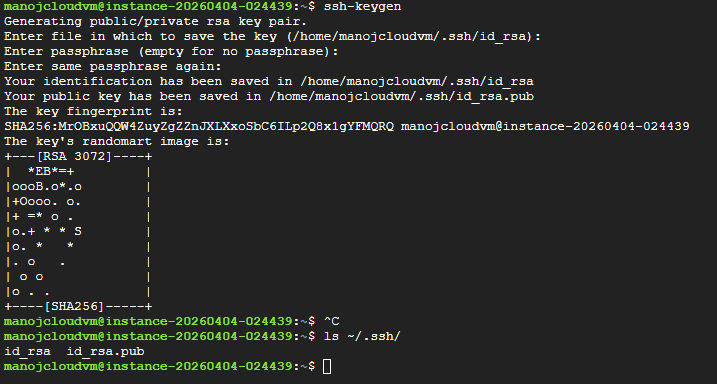

see the public key: `cat ~/.ssh/id_rsa.pub`
It will print something like: ssh-rsa AAAAB3NzaC1yc2EAAAADAQABAAABgQ... manojcloudvm@instance-20260404-024439


You add your .pub to server using `cat ~/.ssh/id_rsa.pub >> ~/.ssh/authorized_keys` and also fix permissions 
`chmod 700 ~/.ssh`
`chmod 600 ~/.ssh/authorized_keys`

Usually you will do this, client  vs remote server access (example, like github access)
Better way to think: the server says, “If you can prove you own the private key that matches one of these public keys, I’ll let you in.”
You can re-use same keys by adding the same to multiple servers

symmetric and asymmetric for webapps:

On the webserver - Admin sets the below:
 run
 `openssl genrsa -out site.key 2048` --> generates a private key called site.key
 then run,
 `openssl rsa -in site.key -pubout > site.pem`--> derives the matching site.pem (public key) from the above site.key (private key)


modern commands for the same use (Apr 2026)
`openssl genpkey -algorithm RSA -pkeyopt rsa_keygen_bits:2048 -out site.key`
`openssl pkey -in site.key -pubout -out site.pem`


When user first access the new website, user browser gets the copy of the site.pem (public key), the user's browser then ...
Server has private key* and public key
When Browser hits the server, server sends to browser its public key*****
>Browser creates a symmetric session key
Browser encrypts that symmetric key with the server’s public key
Browser sends that to the server***** (encrypted symmentric key along with server's public key)
Server decrypts (encrypted symmentric key along with server's public key) with its private key
Now both (browser and server) have the same symmetric key* ---> hacker only has the encrypted symmentric key and server's public key and have no info to decrypt it<---

Then actual data uses symmetric encryption for future comms

Validating the website: Certificate

Hacker can also replicate the website and may trick you. So, 
validating this step is critical "When Browser hits the server, server sends to browser its public key*****", it must be a valid public key from valid website. How do we trust the website? Certs

so,

"When Browser hits the server, server sends to browser, its public key***** + Certificate
`certificate` is a richer signed document that includes the public key plus identity info

Very simply, a certificate contains things like:
the website/domain name
the website’s public key
who issued it
validity dates
a digital signature from the issuer

User entered URL must match the subject/s Alt *****
---
How do you validate this Certificate?
Solution: Who signed it? either its from a CA or self-signed (its only from tesing purposes, do value/trust outside)
Hackers usually something like self-served, Browsers do not trust and warns you if its not from a proper CA. "Connection is not private"



“step-by-step CA style” version to get a valid cert:
1. `openssl genpkey -algorithm RSA -pkeyopt rsa_keygen_bits:2048 -out site.key` --> you are generating a p key for your webserver/website. If you already have it you can use it. You get a file site.key.
2. Certificate Signing Request (CSR): `openssl req -new -key site.key -out site.csr -subj "/C=CA/ST=Ontario/L=Ottawa/O=InfraLab/CN=my-example-website.com"`---> generates a CSR file site.csr
- Notice domain name of your website at CN=my-example-website.com
- Notice Subject

3. Getting signed by CA: You need the 1., 2.  and reachout to CA
Traditional CA → copy-paste CSR (which already has the details of your pkey as you derived CSR from it using above command) into CA order form + provide them a proof you control the domain (Buy from a DNS registrar )

---
For a real public website, the most common beginner path is:

1. point domain DNS to your server ---> It means your domain name like my-example-website.com must have a DNS record that maps to your server’s public IP address---> usually you need to register/buy a domain name from a domain registrar ---> buy my-example-website.com--->then point its DNS records to your server IP (buy my-example-website.com
then point its DNS records to your server IP)
2. use Certbot
3. Certbot handles the CA challenge automatically.

---
the certificate can be free, but the domain usually is not. Let’s Encrypt provides free TLS certificates, but to get one for your website’s domain you still need to control a domain, and in practice that usually means paying a registrar for the domain name.

So the split is:

CA / certificate: free with Let’s Encrypt
domain name: usually paid to a registrar
server/hosting: also usually paid

So “HTTPS with Let’s Encrypt” can be free on the certificate side, but not necessarily free overall.
